# Visualization of RSMs

Lets compare the RSMs
- between the 2 methods (cosine similarity vs spearman)
- between ROIs
- between subjects

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the base directory
base_dir = '/home/hmueller2/ibc_code/'

# Define the paths to the RSMs
rsm_spearman_path = os.path.join(base_dir, 'ibc_output_RSA_spearman')
rsm_cosine_path = os.path.join(base_dir, 'ibc_output_RSA_cosine')

# Print the paths to verify
print(f"Spearman RSM path: {rsm_spearman_path}")
print(f"Cosine RSM path: {rsm_cosine_path}")

Spearman RSM path: /home/hmueller2/ibc_code/ibc_output_RSA_spearman
Cosine RSM path: /home/hmueller2/ibc_code/ibc_output_RSA_cosine


In [2]:
# DEFINITIONS
subject = 'sub-02'
parcel = 'random' # choose specific or 'random'
method = 'cosine' # choose 'cosine' or 'spearman'

if parcel == "random":
    # List all files in the spearman RSM path for the subject
    if method == 'cosine':
        files = os.listdir(os.path.join(rsm_cosine_path, subject))
    elif method == 'spearman':
        files = os.listdir(os.path.join(rsm_spearman_path, subject))
    # Filter files to only include CSV files
    csv_files = [f for f in files if f.endswith('.csv')]
    # Select a random file
    selected_file = np.random.choice(csv_files)
    parcel = '_'.join(selected_file.split('_')[1:3])
else:
    parcel = parcel

# Print chosen ones
print(f"Selected subject: {subject}")
print(f"Selected parcel: {parcel}")
print(f"Selected method: {method}")

Selected subject: sub-02
Selected parcel: L_a9-46v
Selected method: cosine


## 1. Cosine vs Spearman

Plot saved at: /home/hmueller2/ibc_code/ibc_latent/images_presentation/rsm_comparison.png


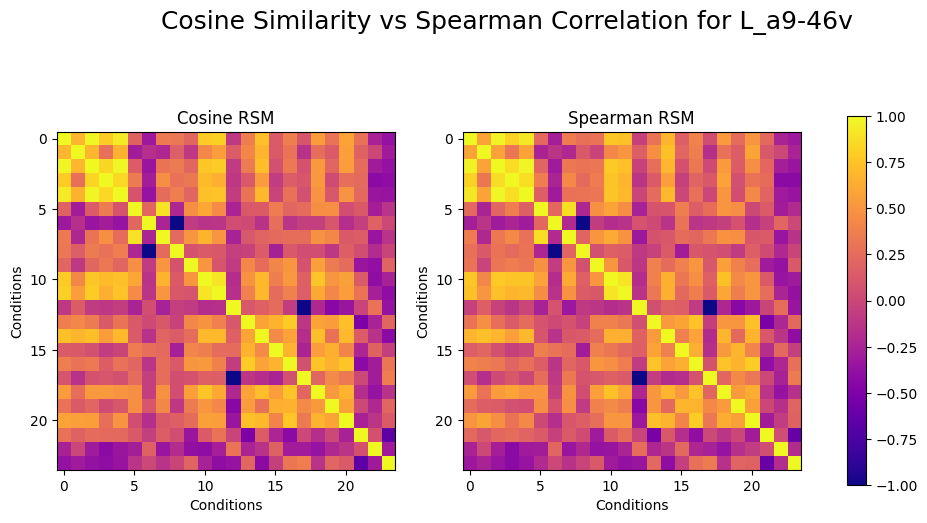

In [4]:
# Load the RSMs for the subject and parcel
rsm_spearman = np.loadtxt(os.path.join(rsm_spearman_path, subject, f'rsm_{parcel}_ROI_{subject}_all-contrasts_method-spearman.csv'), delimiter=',')
rsm_cosine = np.loadtxt(os.path.join(rsm_cosine_path, subject, f'rsm_{parcel}_ROI_{subject}_all-contrasts_method-cosine.csv'), delimiter=',')

# Plot the RSMs for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im1 = axes[0].imshow(rsm_cosine, cmap='plasma')
axes[0].set_title(f'Cosine RSM')
axes[0].set_xlabel('Conditions')
axes[0].set_ylabel('Conditions')

im2 = axes[1].imshow(rsm_spearman, cmap='plasma')
axes[1].set_title(f'Spearman RSM')
axes[1].set_xlabel('Conditions')
axes[1].set_ylabel('Conditions')

# make one single common colorbar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8)

# Add a big title
plt.suptitle(f"Cosine Similarity vs Spearman Correlation for {parcel}", fontsize=18)

# Save the plot in high resolution
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'rsm_comparison.png')
fig.savefig(output_path, dpi=300)
print(f"Plot saved at: {output_path}")


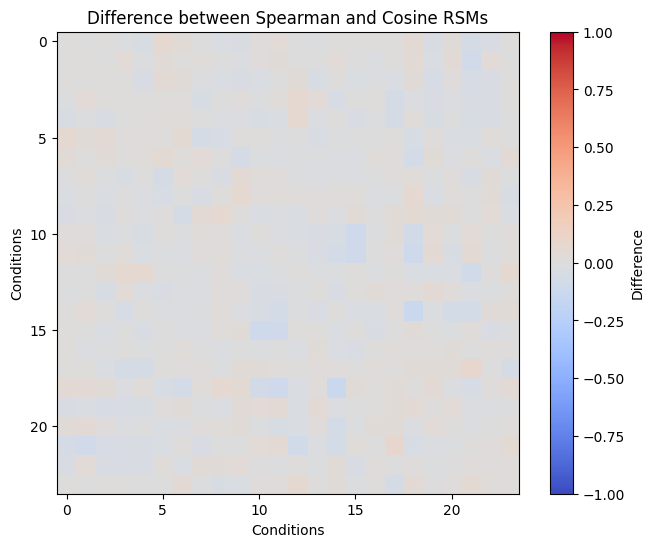

Maximum difference between the matrices: 0.1323049940540501


In [11]:
# Calculate the difference between the two matrices
difference_matrix = rsm_spearman - rsm_cosine

# Plot the difference matrix
plt.figure(figsize=(8, 6))
plt.imshow(difference_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Difference')
plt.title('Difference between Spearman and Cosine RSMs')
plt.xlabel('Conditions')
plt.ylabel('Conditions')
plt.show()

# Print the maximum difference
max_difference = np.max(np.abs(difference_matrix))
print(f"Maximum difference between the matrices: {max_difference}")

## 2. ROI vs ROI

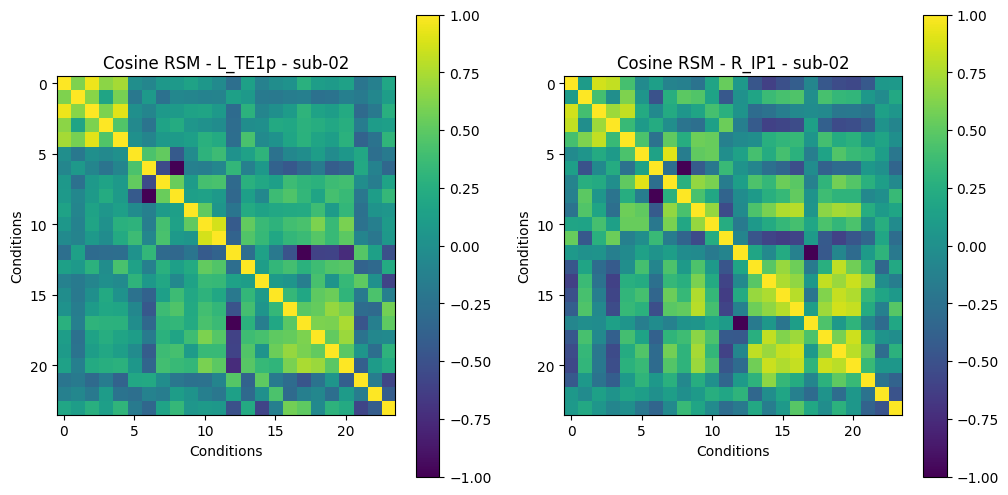

In [ ]:
# Define the method to use for the comparison
method = 'cosine'

# Define the parcel to compare
parcel_compare = 'random' # choose specific or 'random'
if parcel_compare == "random":
    # List all files in the spearman RSM path for the subject
    if method == 'cosine':
        files = os.listdir(os.path.join(rsm_cosine_path, subject))
    elif method == 'spearman':
        files = os.listdir(os.path.join(rsm_spearman_path, subject))
    # Filter files to only include CSV files
    csv_files = [f for f in files if f.endswith('.csv')]
    # Select a random file
    selected_file = np.random.choice(csv_files)
    parcel_compare = '_'.join(selected_file.split('_')[1:3])
else:
    parcel_compare = parcel_compare

# Load the RSMs for the subject and parcel_compare
rsm_compare = np.loadtxt(os.path.join(eval(f'rsm_{method}_path'), subject, f'rsm_{parcel_compare}_ROI_{subject}_all-contrasts_method-{method}.csv'), delimiter=',')

# Plot the RSMs for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im1 = axes[0].imshow(rsm_cosine if method == 'cosine' else rsm_spearman, cmap='viridis')
axes[0].set_title(f'Cosine RSM - {parcel} - {subject}')
axes[0].set_xlabel('Conditions')
axes[0].set_ylabel('Conditions')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(rsm_compare, cmap='viridis')
axes[1].set_title(f'Cosine RSM - {parcel_compare} - {subject}')
axes[1].set_xlabel('Conditions')
axes[1].set_ylabel('Conditions')
fig.colorbar(im2, ax=axes[1])

plt.show()
# Save the plot in high resolution
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'cosine_similarity_subject_2.png')
fig.savefig(output_path, dpi=300)
print(f"Plot saved at: {output_path}")


## 3. Subject vs Subject

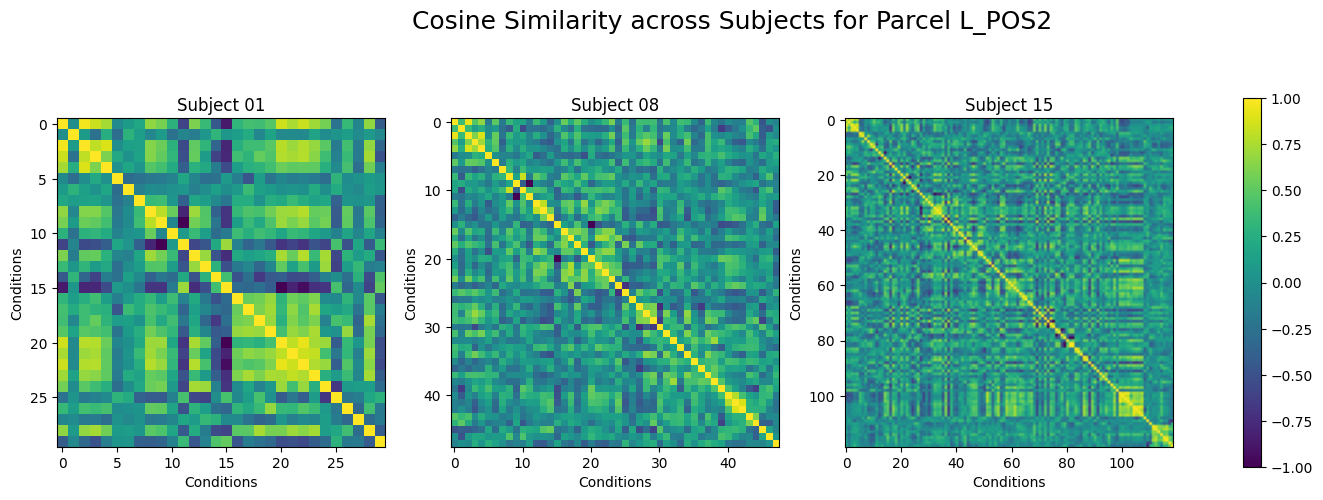

Plot saved at: /home/hmueller2/ibc_code/ibc_latent/images_presentation/rsm_comparison_subjects.png


In [54]:
# Define the subjects to compare
subjects = ['sub-01', 'sub-08', 'sub-15']  # Add more subjects as needed

# Load the RSMs for each subject
rsms = []
for subj in subjects:
    rsm_path = os.path.join(eval(f'rsm_{method}_path'), subj, f'rsm_{parcel}_ROI_{subj}_all-contrasts_method-{method}.csv')
    rsms.append(np.loadtxt(rsm_path, delimiter=','))

# Plot the RSMs for comparison
fig, axes = plt.subplots(1, len(subjects), figsize=(18, 6))
for i, (rsm, subj) in enumerate(zip(rsms, subjects)):
    im = axes[i].imshow(rsm, cmap='viridis') # I like 'inferno', 'magma' and 'viridis'
    axes[i].set_title(f'Subject {subj.split("-")[1]}')
    axes[i].set_xlabel('Conditions')
    axes[i].set_ylabel('Conditions')

# make one single common colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
# Add a big title with adjusted position
plt.suptitle(f"Cosine Similarity across Subjects for Parcel {parcel}", fontsize=18, y=0.95)

plt.show()

# Save the plot in high resolution
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'rsm_comparison_subjects.png')
fig.savefig(output_path, dpi=300)
print(f"Plot saved at: {output_path}")

## 4. RA: Topographic alignment

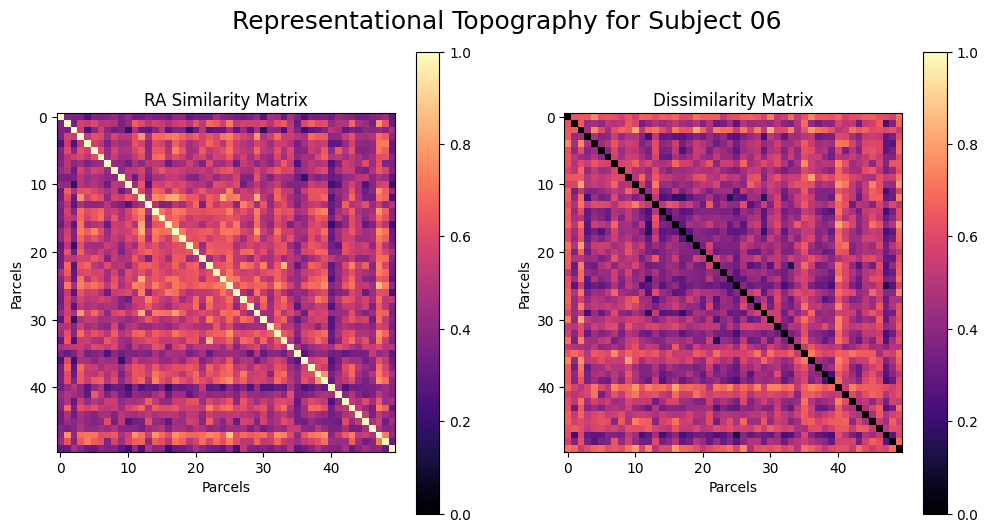

Plot saved at: /home/hmueller2/ibc_code/ibc_latent/images_presentation/ra_sim_and_dissim.png


In [69]:
subject = 'sub-06'

# Define the path to the topographic alignment file for the subject
topographic_alignment_RSM = os.path.join(base_dir, 'ibc_output_RA', 'raw', 'topographic_alignment', 'rsm', f'topographic_alignment_rsm_{subject}.npy')
topographic_alignment_RDM = os.path.join(base_dir, 'ibc_output_RA', 'raw', 'topographic_alignment', 'rdm', f'topographic_alignment_rdm_{subject}.npy')

# Load the topographic alignment data
topographic_alignment_RSM_data = np.load(topographic_alignment_RSM)
topographic_alignment_RDM_data = np.load(topographic_alignment_RDM)

# Plot the topographic alignment data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im1 = axes[0].imshow(topographic_alignment_RSM_data, cmap='magma', vmin=0, vmax=1)
axes[0].set_title(f'RA Similarity Matrix')
axes[0].set_xlabel('Parcels')
axes[0].set_ylabel('Parcels')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(topographic_alignment_RDM_data, cmap='magma', vmin=0, vmax=1)
axes[1].set_title(f'Dissimilarity Matrix')
axes[1].set_xlabel('Parcels')
axes[1].set_ylabel('Parcels')
fig.colorbar(im2, ax=axes[1])

# Add a big title with adjusted position
plt.suptitle(f"Representational Topography for Subject {subject.split("-")[1]}", fontsize=18, y=0.95)

plt.show()

# Save the plot in high resolution
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'ra_sim_and_dissim.png')
fig.savefig(output_path, dpi=300)
print(f"Plot saved at: {output_path}")

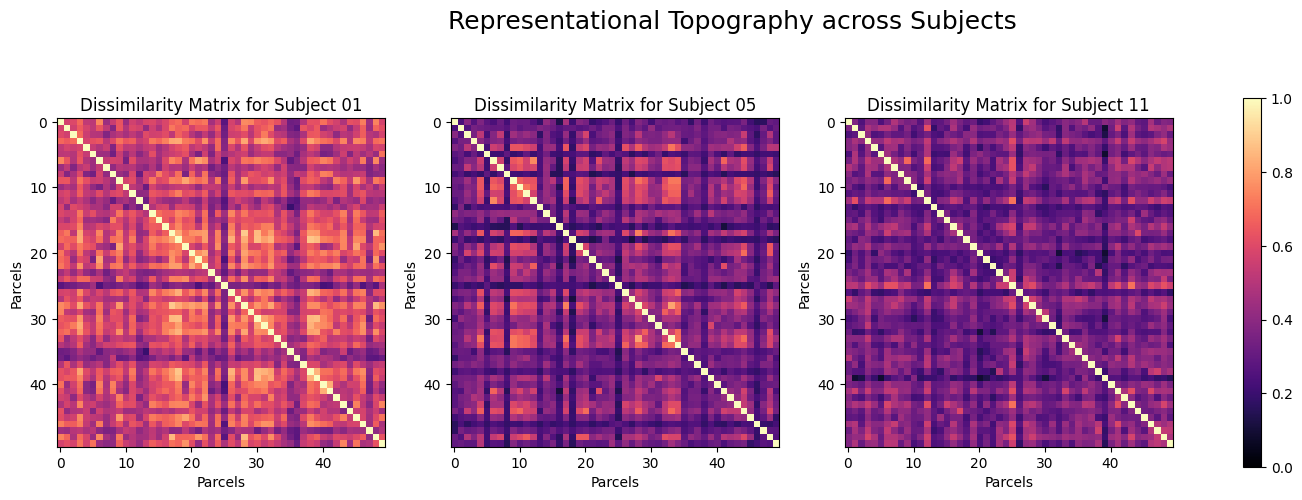

Plot saved at: /home/hmueller2/ibc_code/ibc_latent/images_presentation/rerpresentation_topography.png


In [77]:
# Define the subjects to compare
subjects = ['sub-01', 'sub-05', 'sub-11']  # Add more subjects as needed

# Load the RDMs for each subject
rsms = []
for subj in subjects:
    rsm_path = os.path.join(base_dir, 'ibc_output_RA', 'raw', 'topographic_alignment', 'rsm', f'topographic_alignment_rsm_{subj}.npy')
    rsms.append(np.load(rsm_path))

# Load the topographic alignment data
topographic_alignment_RDM_data = np.load(topographic_alignment_RDM)

# Plot the representational topography data
fig, axes = plt.subplots(1, len(subjects), figsize=(18, 6))
for i, (rsm, subj) in enumerate(zip(rsms, subjects)):
    im = axes[i].imshow(rsm, cmap='magma', vmin=0, vmax=1)  # Correctly set cmap, vmin, and vmax here
    axes[i].set_title(f'Dissimilarity Matrix for Subject {subj.split("-")[1]}')
    axes[i].set_xlabel('Parcels')
    axes[i].set_ylabel('Parcels')

# make one single common colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)

# Add a big title with adjusted position
plt.suptitle(f"Representational Topography across Subjects", fontsize=18, y=0.95)

plt.show()

# Save the plot in high resolution
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'rerpresentation_topography.png')
fig.savefig(output_path, dpi=300)
print(f"Plot saved at: {output_path}")

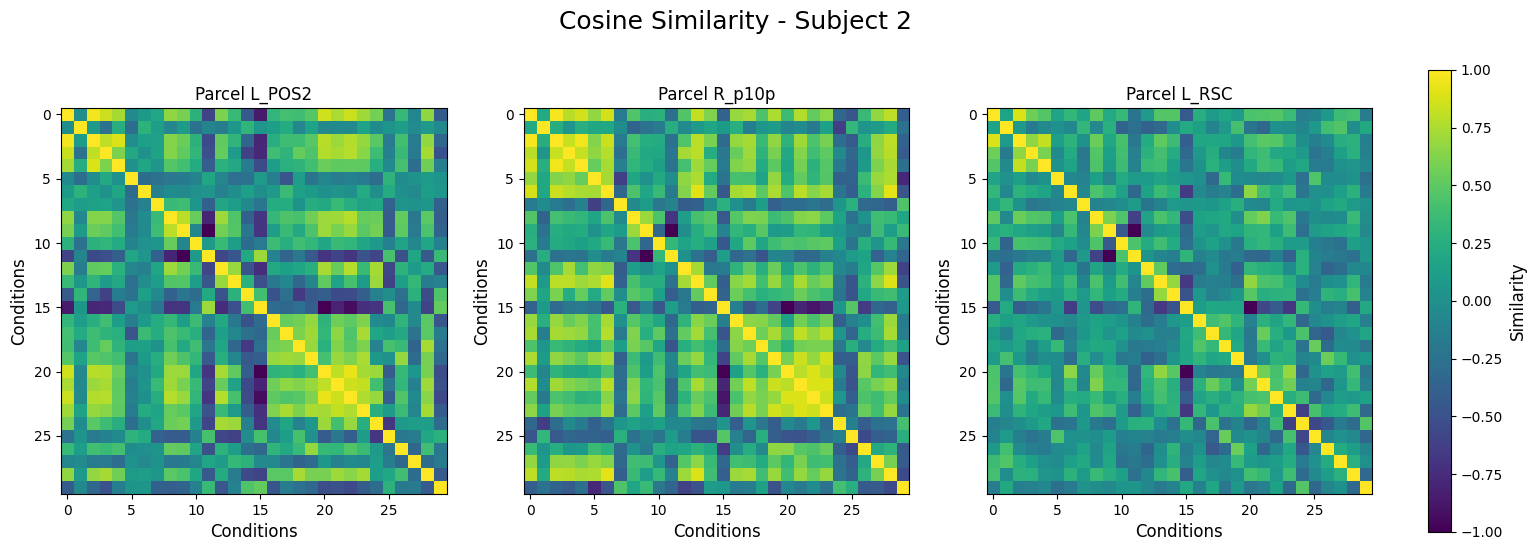

Plot saved at: /home/hmueller2/ibc_code/ibc_latent/images_presentation/cosine_similarity_subject_2.png


In [30]:
# Define the method to use for the comparison
method = 'cosine'
subject = 'sub-01'
rsm_cosine = np.loadtxt(os.path.join(rsm_cosine_path, subject, f'rsm_{parcel}_ROI_{subject}_all-contrasts_method-cosine.csv'), delimiter=',')


# Define the parcels to compare
parcel_compare_1 = 'random'  # choose specific or 'random'
parcel_compare_2 = 'random'  # choose specific or 'random'

# Select random parcels if set to "random"
if parcel_compare_1 == "random":
    selected_file_1 = np.random.choice(csv_files)
    parcel_compare_1 = '_'.join(selected_file_1.split('_')[1:3])

if parcel_compare_2 == "random":
    selected_file_2 = np.random.choice(csv_files)
    parcel_compare_2 = '_'.join(selected_file_2.split('_')[1:3])

# Load the RSMs for the subject and parcels
rsm_compare_1 = np.loadtxt(os.path.join(rsm_cosine_path, subject, f'rsm_{parcel_compare_1}_ROI_{subject}_all-contrasts_method-{method}.csv'), delimiter=',')
rsm_compare_2 = np.loadtxt(os.path.join(rsm_cosine_path, subject, f'rsm_{parcel_compare_2}_ROI_{subject}_all-contrasts_method-{method}.csv'), delimiter=',')

# Plot the RSMs for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im1 = axes[0].imshow(rsm_cosine if method == 'cosine' else rsm_spearman, cmap='viridis')
axes[0].set_title(f"Parcel {parcel}")
axes[0].set_xlabel('Conditions', fontsize=12)
axes[0].set_ylabel('Conditions', fontsize=12)
#fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(rsm_compare_1, cmap='viridis')
axes[1].set_title(f"Parcel {parcel_compare_1}")
axes[1].set_xlabel('Conditions', fontsize=12)
axes[1].set_ylabel('Conditions', fontsize=12)
#fig.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(rsm_compare_2, cmap='viridis')
axes[2].set_title(f"Parcel {parcel_compare_2}")
axes[2].set_xlabel('Conditions', fontsize=12)
axes[2].set_ylabel('Conditions', fontsize=12)
#fig.colorbar(im3, ax=axes[2])

# Add a common colorbar for the three plots
cbar = fig.colorbar(im3, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Similarity', fontsize=12)

# Add a big title
plt.suptitle("Cosine Similarity - Subject 2", fontsize=18)

plt.show()

# Save the plot in high resolution
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'cosine_similarity_subject_2.png')
fig.savefig(output_path, dpi=300)
print(f"Plot saved at: {output_path}")